# PatchCore - Results Analysis
Notebook for visualizing results produced by `evaluate()` and `evaluate_from_db()`.

**Supported inputs:**
- CSV from `evaluate()` - columns: `name, mu, sigma, threshold, free_scores, fp_count, obstr_score, is_tp`
- CSV from `evaluate_from_db()` - columns: `reference_id, test_id, test_type, venue_type, file_path, score, threshold, is_anomaly`
- SQLite DB (optional) - tables `experiments` + `results`

Set the paths in the configuration cell, then run everything with **Run All**.

In [15]:
# ── Dependencies ────────────────────────────────────────────────────────────────
# pip install pandas matplotlib seaborn scikit-learn opencv-python pillow

import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score, roc_curve, roc_auc_score, precision_recall_curve

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


In [16]:
# ── Configuration ────────────────────────────────────────────────────────────

NOTEBOOK_DIR = Path(__file__).parent if '__file__' in dir() else Path.cwd()
SOURCE = 'evaluate_db'  # or 'evaluate' for simple CSV
CSV_PATH = 'results_poli_ingegneria.csv'
DB_PATH = None  # e.g., 'occlusion.db'

def resolve_input_path(raw_path: str) -> Path:
    """Resolve a file path by checking multiple roots."""
    candidate = Path(raw_path)
    if candidate.is_absolute():
        return candidate
    search_roots = [NOTEBOOK_DIR, NOTEBOOK_DIR.parent]
    for root in search_roots:
        resolved = (root / candidate).resolve()
        if resolved.exists():
            return resolved
    return (NOTEBOOK_DIR.parent / candidate).resolve()

CSV_FILE = resolve_input_path(CSV_PATH)
print(f'CSV file resolved to: {CSV_FILE}')
print(f'File exists: {CSV_FILE.exists()}')

CSV file resolved to: C:\Users\andrea\OneDrive - University of Pisa\Università\Unipi\tesi\src\results_poli_ingegneria.csv
File exists: True


---
## 1. Data Loading

In [17]:
# ── Load CSV and normalize to common format ──────────────────────────────────

def load_evaluate_csv(path: str) -> pd.DataFrame:
    """CSV from evaluate() - one row per background image."""
    df = pd.read_csv(path)
    # free_scores is stored as JSON string '[0.123, ...]'
    df['free_scores'] = df['free_scores'].apply(json.loads)
    # Expand into separate rows (one for each free test)
    free_rows = []
    for _, row in df.iterrows():
        for s in row['free_scores']:
            free_rows.append({
                'name': row['name'],
                'score': s,
                'threshold': row['threshold'],
                'test_type': 'normal',
                'is_anomaly': int(s > row['threshold']),
                'venue_type': 'n/a',
            })
        if pd.notna(row.get('obstr_score')):
            free_rows.append({
                'name': row['name'],
                'score': row['obstr_score'],
                'threshold': row['threshold'],
                'test_type': 'obstructed',
                'is_anomaly': int(row['is_tp']) if pd.notna(row.get('is_tp')) else None,
                'venue_type': 'n/a',
            })
    return pd.DataFrame(free_rows)


def load_evaluate_db_csv(path: str) -> pd.DataFrame:
    """CSV from evaluate_from_db() - one row per (reference, test) pair."""
    df = pd.read_csv(path)
    df['is_anomaly'] = df['is_anomaly'].astype(int)
    return df


if SOURCE == 'evaluate':
    df = load_evaluate_csv(str(CSV_FILE))
else:
    df = load_evaluate_db_csv(str(CSV_FILE))

print(f'Rows loaded: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head()

Rows loaded: 30
Columns: ['reference_id', 'test_id', 'test_type', 'venue_type', 'file_path', 'score', 'normalized_score', 'threshold', 'is_anomaly', 'mu', 'sigma', 'gated']


,reference_id,test_id,test_type,venue_type,file_path,score,normalized_score,threshold,is_anomaly,mu,sigma,gated
0,non_ostruite/poli ingegneria/porta_1.jpg,non_ostruite/poli ingegneria/porta_1.jpg,normal,porta,non_ostruite/poli ingegneria/porta_1.jpg,0.0,-9.022628,4.133851,0,2.864107,0.40734,1
1,non_ostruite/poli ingegneria/porta_1.jpg,ostruzioni_poli_ingegneria/dietro_vetro_o_post...,bg_normal,porta,ostruzioni_poli_ingegneria/dietro_vetro_o_post...,0.0,-9.022628,4.133851,0,2.864107,0.40734,1
2,non_ostruite/poli ingegneria/porta_1.jpg,ostruzioni_poli_ingegneria/davanti_centro/port...,obstructed,porta,ostruzioni_poli_ingegneria/davanti_centro/port...,0.0,-9.022628,4.133851,0,2.864107,0.40734,1
3,non_ostruite/poli ingegneria/porta_1.jpg,ostruzioni_poli_ingegneria/davanti_destra/port...,obstructed,porta,ostruzioni_poli_ingegneria/davanti_destra/port...,0.0,-9.022628,4.133851,0,2.864107,0.40734,1
4,non_ostruite/poli ingegneria/porta_1.jpg,ostruzioni_poli_ingegneria/davanti_sinistra/po...,obstructed,porta,ostruzioni_poli_ingegneria/davanti_sinistra/po...,0.0,-9.022628,4.133851,0,2.864107,0.40734,1


In [18]:
# ── Split data by test_type ─────────────────────────────────────────────────

normal_df     = df[df['test_type'] == 'normal']
obstructed_df = df[df['test_type'] == 'obstructed']
shadow_df     = df[df['test_type'] == 'shadow_normal']
light_df      = df[df['test_type'] == 'light_normal']
bg_df         = df[df['test_type'] == 'bg_normal']

print(f'Normal:     {len(normal_df)} rows')
print(f'Obstructed: {len(obstructed_df)} rows')
print(f'Shadow:     {len(shadow_df)} rows')
print(f'Light:      {len(light_df)} rows')
print(f'Bg-change:  {len(bg_df)} rows')
print(f'Total:      {len(df)} rows')
print(f'test_type values in CSV: {sorted(df["test_type"].unique())}')


Normal:     6 rows
Obstructed: 18 rows
Shadow:     0 rows
Light:      0 rows
Bg-change:  6 rows
Total:      30 rows
test_type values in CSV: ['bg_normal', 'normal', 'obstructed']


---
## 2. Anomaly Score Distribution

C:\Users\andrea\AppData\Local\Temp\ipykernel_21820\2472995661.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_to_plot, labels=labels)


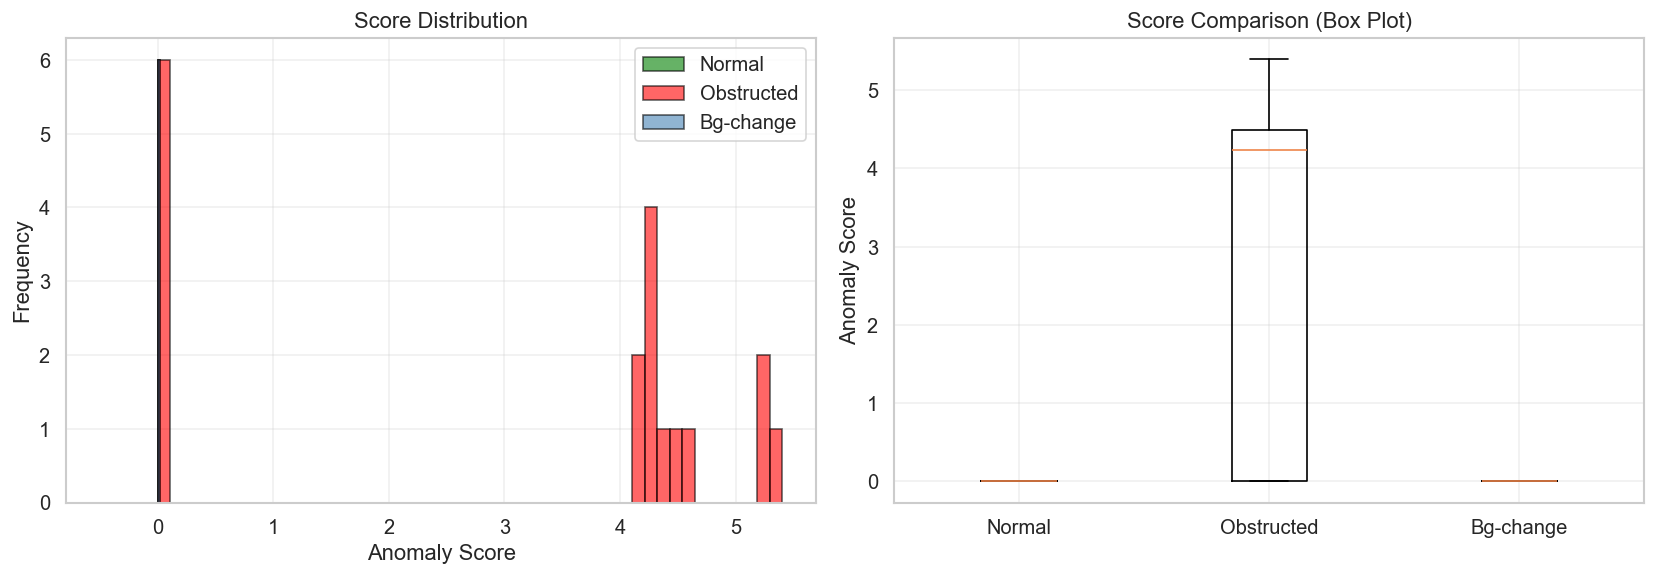

=== Score Statistics ===
Normal:     mean=0.0000, std=0.0000
Obstructed: mean=3.0454, std=2.2452
Bg-change:  mean=0.0000, std=0.0000


In [19]:
# ── Score distribution ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(normal_df['score'],     bins=50, alpha=0.6, label='Normal',     color='green',     edgecolor='black')
axes[0].hist(obstructed_df['score'], bins=50, alpha=0.6, label='Obstructed', color='red',       edgecolor='black')
if len(shadow_df) > 0:
    axes[0].hist(shadow_df['score'], bins=50, alpha=0.6, label='Shadow',    color='orange',    edgecolor='black')
if len(light_df) > 0:
    axes[0].hist(light_df['score'],  bins=50, alpha=0.6, label='Light',     color='gold',      edgecolor='black')
if len(bg_df) > 0:
    axes[0].hist(bg_df['score'],     bins=50, alpha=0.6, label='Bg-change', color='steelblue', edgecolor='black')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Score Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

data_to_plot = [normal_df['score'], obstructed_df['score']]
labels = ['Normal', 'Obstructed']
if len(shadow_df) > 0:
    data_to_plot.append(shadow_df['score']); labels.append('Shadow')
if len(light_df) > 0:
    data_to_plot.append(light_df['score']);  labels.append('Light')
if len(bg_df) > 0:
    data_to_plot.append(bg_df['score']);     labels.append('Bg-change')
axes[1].boxplot(data_to_plot, labels=labels)
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Score Comparison (Box Plot)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('=== Score Statistics ===')
print(f'Normal:     mean={normal_df["score"].mean():.4f}, std={normal_df["score"].std():.4f}')
print(f'Obstructed: mean={obstructed_df["score"].mean():.4f}, std={obstructed_df["score"].std():.4f}')
if len(shadow_df) > 0:
    print(f'Shadow:     mean={shadow_df["score"].mean():.4f}, std={shadow_df["score"].std():.4f}')
if len(light_df) > 0:
    print(f'Light:      mean={light_df["score"].mean():.4f}, std={light_df["score"].std():.4f}')
if len(bg_df) > 0:
    print(f'Bg-change:  mean={bg_df["score"].mean():.4f}, std={bg_df["score"].std():.4f}')


---
## 3. ROC Curve and Precision-Recall

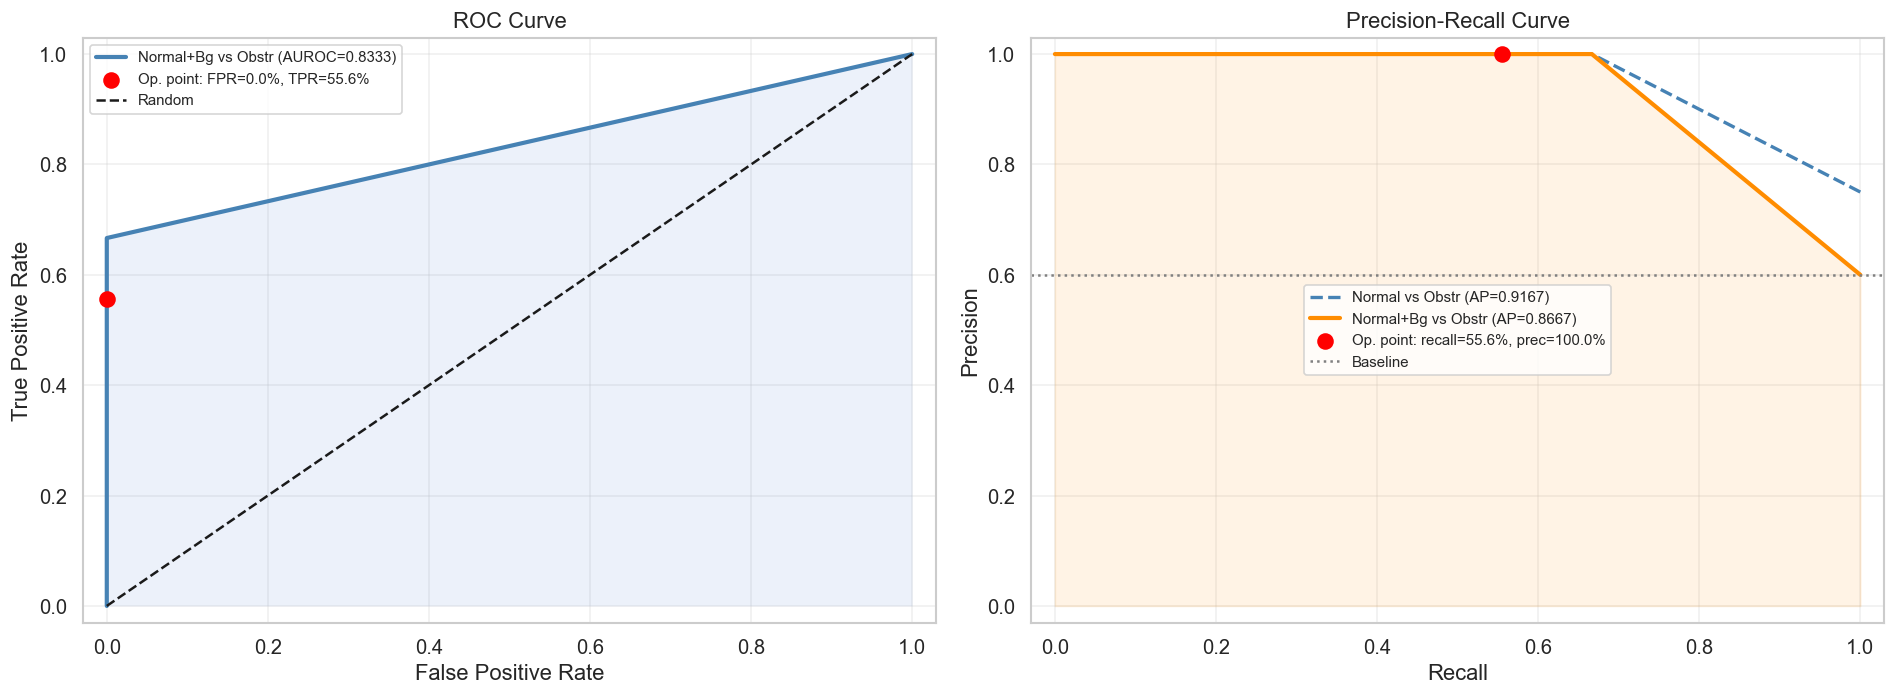

AUROC (Normal+Bg vs Obstr): 0.8333
AP    (Normal+Bg vs Obstr): 0.8667
AP    (Normal only vs Obstr):          0.9167

Operating point (per-reference adaptive thresholds):
  Normal FPR:    0.00%
  Bg-change FPR: 0.00%
  Combined FPR:  0.00%
  Obstr TPR:     55.56%
  Obstr FNR:     44.44%


In [20]:
# ── ROC Curve and Precision-Recall ──────────────────────────────────────────

has_shadow = len(shadow_df) > 0
has_light  = len(light_df) > 0
has_bg     = len(bg_df) > 0
has_disturbance = has_shadow or has_light or has_bg

scores_no = pd.concat([normal_df['score'], obstructed_df['score']], ignore_index=True)
labels_no = pd.concat([pd.Series([0]*len(normal_df)), pd.Series([1]*len(obstructed_df))], ignore_index=True)
prec_c, rec_c, _ = precision_recall_curve(labels_no, scores_no)
ap_clean = average_precision_score(labels_no, scores_no)

disturbance_dfs = [normal_df]
if has_shadow: disturbance_dfs.append(shadow_df)
if has_light:  disturbance_dfs.append(light_df)
if has_bg:     disturbance_dfs.append(bg_df)
disturbance_combined = pd.concat(disturbance_dfs, ignore_index=True)

if has_disturbance:
    scores_full = pd.concat([disturbance_combined['score'], obstructed_df['score']], ignore_index=True)
    labels_full = pd.concat([
        pd.Series([0]*len(disturbance_combined)),
        pd.Series([1]*len(obstructed_df))
    ], ignore_index=True)
    fpr_full, tpr_full, thr_full = roc_curve(labels_full, scores_full)
    auroc = roc_auc_score(labels_full, scores_full)
    prec_full, rec_full, _ = precision_recall_curve(labels_full, scores_full)
    ap = average_precision_score(labels_full, scores_full)
else:
    fpr_full, tpr_full, thr_full = roc_curve(labels_no, scores_no)
    auroc = roc_auc_score(labels_no, scores_no)
    prec_full, rec_full = prec_c, rec_c
    ap = ap_clean

op_normal_fpr  = normal_df['is_anomaly'].mean()
op_obstr_tpr   = obstructed_df['is_anomaly'].mean()
fp_op = normal_df['is_anomaly'].sum()
tp_op = obstructed_df['is_anomaly'].sum()
op_shadow_fpr = shadow_df['is_anomaly'].mean() if has_shadow else None
op_light_fpr  = light_df['is_anomaly'].mean()  if has_light  else None
op_bg_fpr     = bg_df['is_anomaly'].mean()     if has_bg     else None
if has_shadow: fp_op += shadow_df['is_anomaly'].sum()
if has_light:  fp_op += light_df['is_anomaly'].sum()
if has_bg:     fp_op += bg_df['is_anomaly'].sum()
op_fpr_combined = disturbance_combined['is_anomaly'].sum() / len(disturbance_combined)
op_obstr_prec   = tp_op / max(tp_op + fp_op, 1)

parts = ['Normal']
if has_shadow: parts.append('Shadow')
if has_light:  parts.append('Light')
if has_bg:     parts.append('Bg')
label_disturbance = '+'.join(parts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(fpr_full, tpr_full, lw=2.5, color='steelblue',
             label=f'{label_disturbance} vs Obstr (AUROC={auroc:.4f})')
axes[0].scatter([op_fpr_combined], [op_obstr_tpr], color='red', zorder=5, s=80,
                label=f'Op. point: FPR={op_fpr_combined:.1%}, TPR={op_obstr_tpr:.1%}')
axes[0].plot([0,1],[0,1],'k--',lw=1.5,label='Random')
axes[0].fill_between(fpr_full, tpr_full, alpha=0.1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[0].set_xlim([-0.03,1.03]); axes[0].set_ylim([-0.03,1.03])

axes[1].plot(rec_c, prec_c, lw=2, color='steelblue', linestyle='--',
             label=f'Normal vs Obstr (AP={ap_clean:.4f})')
if has_disturbance:
    axes[1].plot(rec_full, prec_full, lw=2.5, color='darkorange',
                 label=f'{label_disturbance} vs Obstr (AP={ap:.4f})')
axes[1].scatter([op_obstr_tpr],[op_obstr_prec],color='red',zorder=5,s=80,
                label=f'Op. point: recall={op_obstr_tpr:.1%}, prec={op_obstr_prec:.1%}')
axes[1].axhline(y=labels_full.sum()/len(labels_full),color='gray',linestyle=':',lw=1.5,label='Baseline')
axes[1].fill_between(rec_full, prec_full, alpha=0.1, color='darkorange')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
axes[1].set_xlim([-0.03,1.03]); axes[1].set_ylim([-0.03,1.03])

plt.tight_layout()
plt.show()

print(f'AUROC ({label_disturbance} vs Obstr): {auroc:.4f}')
print(f'AP    ({label_disturbance} vs Obstr): {ap:.4f}')
print(f'AP    (Normal only vs Obstr):          {ap_clean:.4f}')
print()
print('Operating point (per-reference adaptive thresholds):')
print(f'  Normal FPR:    {op_normal_fpr:.2%}')
if has_shadow: print(f'  Shadow FPR:    {op_shadow_fpr:.2%}')
if has_light:  print(f'  Light FPR:     {op_light_fpr:.2%}')
if has_bg:     print(f'  Bg-change FPR: {op_bg_fpr:.2%}')
print(f'  Combined FPR:  {op_fpr_combined:.2%}')
print(f'  Obstr TPR:     {op_obstr_tpr:.2%}')
print(f'  Obstr FNR:     {1-op_obstr_tpr:.2%}')


---
## 4. FPR / TPR per venue_type

In [21]:
# ── Per-Venue Analysis (if venue_type available) ──────────────────────────────

if 'venue_type' in df.columns and df['venue_type'].nunique() > 1:
    venues = df['venue_type'].unique()
    fig, axes = plt.subplots(len(venues), 1, figsize=(10, 4*len(venues)))
    if len(venues) == 1:
        axes = [axes]
    
    for i, venue in enumerate(venues):
        venue_df = df[df['venue_type'] == venue]
        normal_venue = venue_df[venue_df['test_type'] == 'normal']
        obstructed_venue = venue_df[venue_df['test_type'] == 'obstructed']
        
        if len(obstructed_venue) > 0:
            labels_venue = pd.concat([
                pd.Series([0] * len(normal_venue)),
                pd.Series([1] * len(obstructed_venue))
            ], ignore_index=True)
            scores_venue = pd.concat([
                normal_venue['score'],
                obstructed_venue['score']
            ], ignore_index=True)
            
            auroc_venue = roc_auc_score(labels_venue, scores_venue)
            fpr_v, tpr_v, _ = roc_curve(labels_venue, scores_venue)
            
            axes[i].plot(fpr_v, tpr_v, lw=2.5, label=f'AUROC={auroc_venue:.4f}')
            axes[i].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
            axes[i].fill_between(fpr_v, tpr_v, alpha=0.2)
            axes[i].set_xlabel('False Positive Rate')
            axes[i].set_ylabel('True Positive Rate')
            axes[i].set_title(f'Venue: {venue}')
            axes[i].legend()
            axes[i].grid(alpha=0.3)
            axes[i].set_xlim([0, 1])
            axes[i].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()

---
## 5. Shadow FPR - Robustness to Synthetic Shadows

No shadow or light test data available.


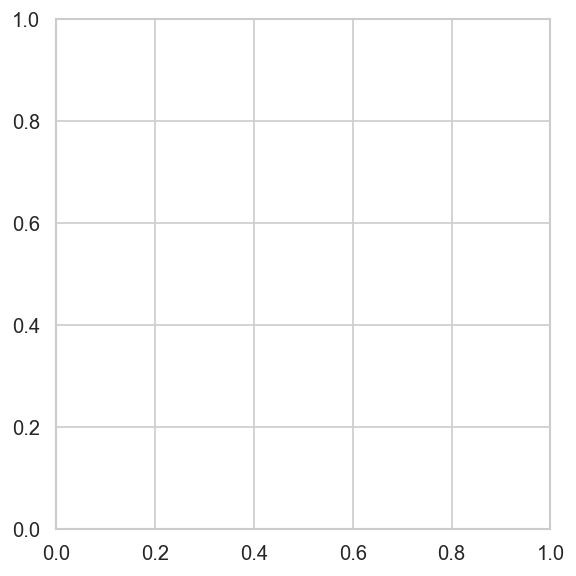

In [22]:
# ── Disturbance FPR: Robustness to synthetic shadows and light beams ──────────
# shadow_normal and light_normal images are NORMAL frames (expected is_anomaly=0).

fig, axes = plt.subplots(1, max(1, int(has_shadow)+int(has_light)), figsize=(11*max(1,int(has_shadow)+int(has_light))//2, 5))
if not isinstance(axes, np.ndarray):
    axes = [axes]
ax_idx = 0

if has_shadow:
    shadow_fp  = (shadow_df['is_anomaly'] == 1).sum()
    shadow_tn  = (shadow_df['is_anomaly'] == 0).sum()
    shadow_fpr_val = shadow_fp / len(shadow_df)
    print(f'Shadow robustness (n={len(shadow_df)}):')
    print(f'  TN: {shadow_tn}  FP: {shadow_fp}  Shadow FPR: {shadow_fpr_val:.4f} ({shadow_fpr_val:.1%})')
    mean_thr = shadow_df['threshold'].mean()
    axes[ax_idx].hist(shadow_df['score'], bins=50, alpha=0.7, color='orange', edgecolor='black', label='Shadow Normal')
    axes[ax_idx].axvline(mean_thr, color='red', linestyle='--', lw=2, label=f'Mean Threshold ({mean_thr:.3f})')
    axes[ax_idx].set_xlabel('Anomaly Score'); axes[ax_idx].set_ylabel('Frequency')
    axes[ax_idx].set_title('Shadow Score Distribution'); axes[ax_idx].legend(); axes[ax_idx].grid(alpha=0.3)
    ax_idx += 1

if has_light:
    light_fp  = (light_df['is_anomaly'] == 1).sum()
    light_tn  = (light_df['is_anomaly'] == 0).sum()
    light_fpr_val = light_fp / len(light_df)
    print(f'Light robustness (n={len(light_df)}):')
    print(f'  TN: {light_tn}  FP: {light_fp}  Light FPR: {light_fpr_val:.4f} ({light_fpr_val:.1%})')
    mean_thr = light_df['threshold'].mean()
    axes[ax_idx].hist(light_df['score'], bins=50, alpha=0.7, color='gold', edgecolor='black', label='Light Normal')
    axes[ax_idx].axvline(mean_thr, color='red', linestyle='--', lw=2, label=f'Mean Threshold ({mean_thr:.3f})')
    axes[ax_idx].set_xlabel('Anomaly Score'); axes[ax_idx].set_ylabel('Frequency')
    axes[ax_idx].set_title('Light Score Distribution'); axes[ax_idx].legend(); axes[ax_idx].grid(alpha=0.3)
    ax_idx += 1

if not has_shadow and not has_light:
    print('No shadow or light test data available.')

plt.tight_layout()
plt.show()


---
## 6. Score per image - ranking

In [23]:
# ── False Positives ─────────────────────────────────────────────────────────

all_normal_df = pd.concat([normal_df, shadow_df, light_df, bg_df], ignore_index=True)

fp_clean  = normal_df[normal_df['is_anomaly'] == 1]
fp_shadow = shadow_df[shadow_df['is_anomaly'] == 1] if has_shadow else pd.DataFrame()
fp_light  = light_df[light_df['is_anomaly'] == 1]   if has_light  else pd.DataFrame()
fp_bg     = bg_df[bg_df['is_anomaly'] == 1]         if has_bg     else pd.DataFrame()
fp_all    = all_normal_df[all_normal_df['is_anomaly'] == 1]

print(f'FPR - clean normal only:          {len(fp_clean)}/{len(normal_df)} = {len(fp_clean)/len(normal_df):.2%}')
if has_shadow:
    print(f'FPR - shadow normal only:         {len(fp_shadow)}/{len(shadow_df)} = {len(fp_shadow)/len(shadow_df):.2%}')
if has_light:
    print(f'FPR - light normal only:          {len(fp_light)}/{len(light_df)} = {len(fp_light)/len(light_df):.2%}')
if has_bg:
    print(f'FPR - bg-change normal only:      {len(fp_bg)}/{len(bg_df)} = {len(fp_bg)/len(bg_df):.2%}')
print(f'FPR - combined (all normal):      {len(fp_all)}/{len(all_normal_df)} = {len(fp_all)/len(all_normal_df):.2%}')

print(f'\nTop 10 FPs (all normal images):')
print(fp_all.sort_values('score', ascending=False)[['test_type','score','threshold','venue_type']].head(10).to_string())

if 'venue_type' in df.columns and len(fp_all) > 0:
    n_cols = 1 + int(has_shadow or has_light or has_bg)
    fig, axes = plt.subplots(1, n_cols, figsize=(6*n_cols, 4))
    if n_cols == 1: axes = [axes]
    fp_all['venue_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Venue Type'); axes[0].set_ylabel('Count')
    axes[0].set_title('False Positives per Venue Type'); axes[0].grid(alpha=0.3)
    if n_cols > 1:
        breakdown = {'Clean': len(fp_clean)}
        colors = ['green']
        if has_shadow: breakdown['Shadow'] = len(fp_shadow); colors.append('orange')
        if has_light:  breakdown['Light']  = len(fp_light);  colors.append('gold')
        if has_bg:     breakdown['Bg']     = len(fp_bg);     colors.append('steelblue')
        pd.Series(breakdown).plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
        axes[1].set_ylabel('Count'); axes[1].set_title('FP Breakdown by Type'); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No false positives.')


FPR - clean normal only:          0/6 = 0.00%
FPR - bg-change normal only:      0/6 = 0.00%
FPR - combined (all normal):      0/12 = 0.00%

Top 10 FPs (all normal images):
Empty DataFrame
Columns: [test_type, score, threshold, venue_type]
Index: []
No false positives.


False Negatives: 8 / 18
False Negative Rate: 0.4444

Bottom 10 FNs (hardest to detect):
       score  threshold venue_type
2   0.000000   4.133851      porta
3   0.000000   4.133851      porta
4   0.000000   4.133851      porta
12  0.000000   4.099028      porta
13  0.000000   4.099028      porta
14  0.000000   4.099028      porta
29  4.240031   4.418204      porta
28  4.386240   4.418204      porta


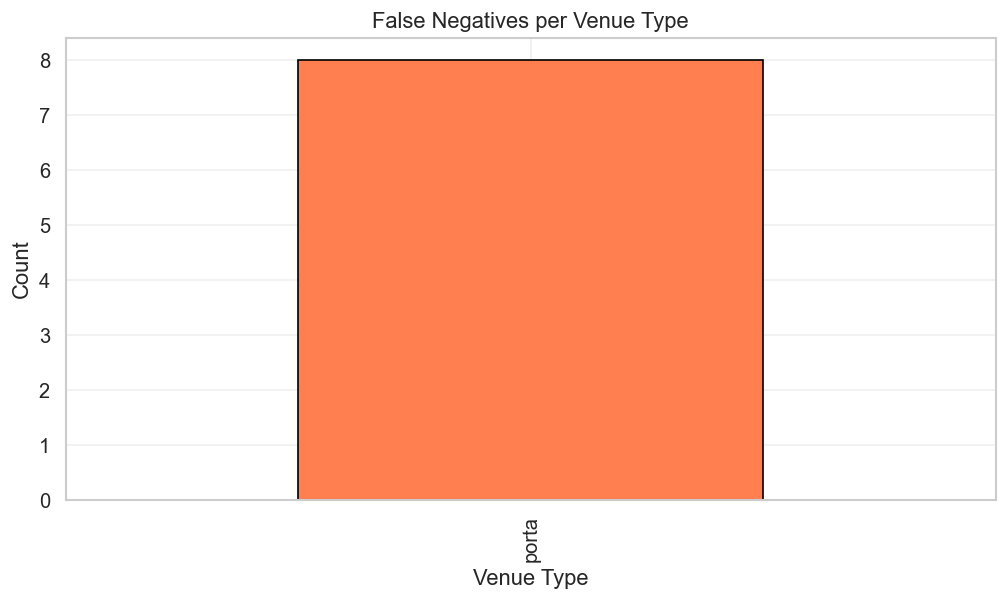

In [24]:
# ── False Negatives ────────────────────────────────────────────────────────────

fn_df = obstructed_df[obstructed_df['is_anomaly'] == 0].sort_values('score', ascending=True)
print(f'False Negatives: {len(fn_df)} / {len(obstructed_df)}')
print(f'False Negative Rate: {len(fn_df)/len(obstructed_df):.4f}')
print('\nBottom 10 FNs (hardest to detect):')
print(fn_df[['score', 'threshold', 'venue_type']].head(10).to_string())

if 'venue_type' in df.columns and len(fn_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    fn_df['venue_type'].value_counts().plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_xlabel('Venue Type')
    ax.set_ylabel('Count')
    ax.set_title('False Negatives per Venue Type')
    ax.grid(alpha=0.3)
    plt.show()
else:
    print('No false negatives.')

---
## 7. Threshold Analysis - FPR / TPR vs k·σ

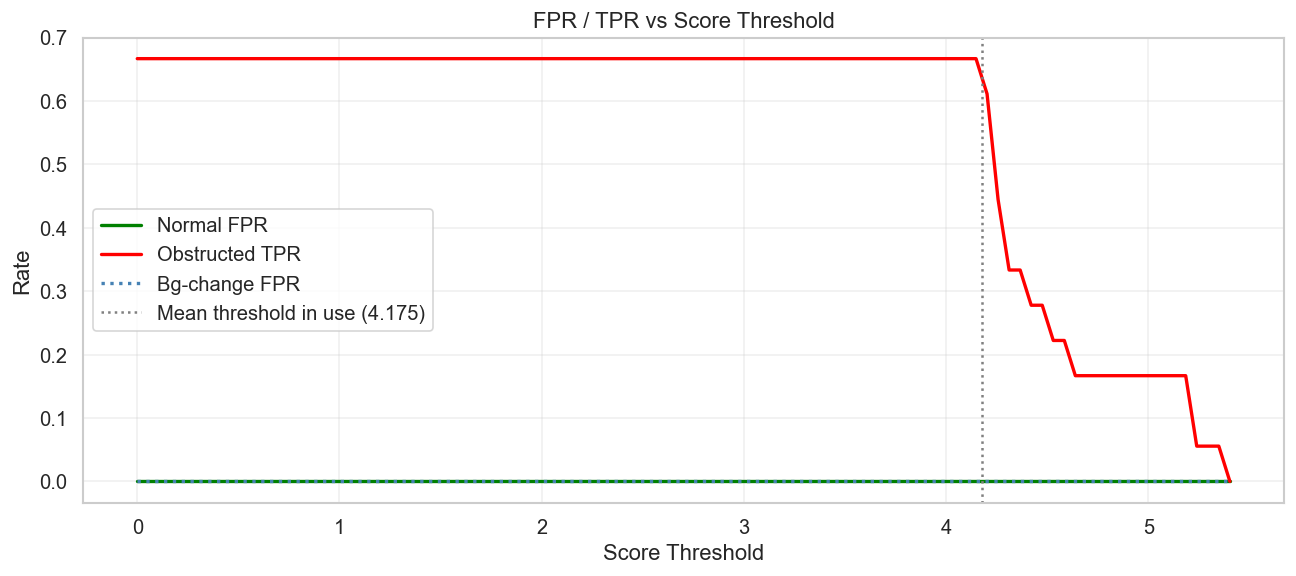

 Threshold |   Normal FPR |   Shadow FPR |    Light FPR |       Bg FPR |    Obstr TPR
     0.000 |        0.0% |          n/a |          n/a |         0.0% |       66.7%
     0.437 |        0.0% |          n/a |          n/a |         0.0% |       66.7%
     0.873 |        0.0% |          n/a |          n/a |         0.0% |       66.7%
     1.310 |        0.0% |          n/a |          n/a |         0.0% |       66.7%
     1.746 |        0.0% |          n/a |          n/a |         0.0% |       66.7%
     2.183 |        0.0% |          n/a |          n/a |         0.0% |       66.7%
     2.619 |        0.0% |          n/a |          n/a |         0.0% |       66.7%
     3.056 |        0.0% |          n/a |          n/a |         0.0% |       66.7%
     3.492 |        0.0% |          n/a |          n/a |         0.0% |       66.7%
     3.929 |        0.0% |          n/a |          n/a |         0.0% |       66.7%
     4.366 |        0.0% |          n/a |          n/a |         0.0% |   

In [25]:
# ── Threshold Sensitivity: FPR / TPR vs Score Threshold ──────────────────────

all_group_scores = pd.concat([normal_df['score'], obstructed_df['score'],
                               shadow_df['score'], light_df['score'], bg_df['score']])
thresholds = np.linspace(all_group_scores.min(), all_group_scores.max(), 100)

normal_fprs, shadow_fprs, light_fprs, bg_fprs, obstr_tprs = [], [], [], [], []
for thr in thresholds:
    normal_fprs.append((normal_df['score'] > thr).mean())
    obstr_tprs.append((obstructed_df['score'] > thr).mean())
    shadow_fprs.append((shadow_df['score'] > thr).mean() if has_shadow else None)
    light_fprs.append((light_df['score'] > thr).mean()  if has_light  else None)
    bg_fprs.append((bg_df['score'] > thr).mean()        if has_bg     else None)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, normal_fprs, label='Normal FPR',     linewidth=2, color='green')
ax.plot(thresholds, obstr_tprs,  label='Obstructed TPR', linewidth=2, color='red')
if has_shadow:
    ax.plot(thresholds, shadow_fprs, label='Shadow FPR',    linewidth=2, color='orange',    linestyle='--')
if has_light:
    ax.plot(thresholds, light_fprs,  label='Light FPR',     linewidth=2, color='gold',      linestyle='-.')
if has_bg:
    ax.plot(thresholds, bg_fprs,     label='Bg-change FPR', linewidth=2, color='steelblue', linestyle=':')

mean_thr_used = normal_df['threshold'].mean()
ax.axvline(mean_thr_used, color='gray', linestyle=':', linewidth=1.5,
           label=f'Mean threshold in use ({mean_thr_used:.3f})')

ax.set_xlabel('Score Threshold'); ax.set_ylabel('Rate')
ax.set_title('FPR / TPR vs Score Threshold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

hdr = f'{"Threshold":>10} | {"Normal FPR":>12} | {"Shadow FPR":>12} | {"Light FPR":>12} | {"Bg FPR":>12} | {"Obstr TPR":>12}'
print(hdr)
step = max(1, len(thresholds) // 12)
for i in range(0, len(thresholds), step):
    thr = thresholds[i]
    sfpr = f'{shadow_fprs[i]:.1%}' if has_shadow else 'n/a'
    lfpr = f'{light_fprs[i]:.1%}'  if has_light  else 'n/a'
    bfpr = f'{bg_fprs[i]:.1%}'     if has_bg     else 'n/a'
    print(f'{thr:>10.3f} | {normal_fprs[i]:>11.1%} | {sfpr:>12} | {lfpr:>12} | {bfpr:>12} | {obstr_tprs[i]:>11.1%}')


---
## 8. Heatmap Visualization (overlay from disk)

In [26]:
# ── Heatmap gallery (load from disk if available) ───────────────────────────────

# This section loads anomaly maps (heatmaps) from disk if they exist
# Expected structure: each row should have a 'heatmap_path' column pointing to a .npy or .png

if 'heatmap_path' in df.columns:
    # Sample a few normal and obstructed
    normal_samples = normal_df.dropna(subset=['heatmap_path']).sample(min(3, len(normal_df)), random_state=42)
    obstr_samples = obstructed_df.dropna(subset=['heatmap_path']).sample(min(3, len(obstructed_df)), random_state=42)
    
    for label, samples in [('Normal', normal_samples), ('Obstructed', obstr_samples)]:
        fig = plt.figure(figsize=(12, 4))
        for idx, (_, row) in enumerate(samples.iterrows()):
            ax = fig.add_subplot(1, 3, idx+1)
            try:
                if row['heatmap_path'].endswith('.npy'):
                    hmap = np.load(row['heatmap_path'])
                    im = ax.imshow(hmap, cmap='hot')
                    plt.colorbar(im, ax=ax)
                else:
                    from PIL import Image
                    img = Image.open(row['heatmap_path'])
                    ax.imshow(img)
                ax.set_title(f"Score: {row['score']:.4f}")
                ax.axis('off')
            except Exception as e:
                ax.text(0.5, 0.5, f'Error loading:\n{str(e)[:30]}', 
                       ha='center', va='center', transform=ax.transAxes)
        fig.suptitle(f'{label} Heatmaps', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print('No heatmap_path column in data.')

No heatmap_path column in data.


---
## 9. Pair Comparison: Normal vs Obstructed

In [27]:
# ── Pair comparison: reference vs test images ────────────────────────────────

if 'reference_id' in df.columns and 'test_id' in df.columns:
    print('Sample reference-test pairs:')
    sample_pairs = df.drop_duplicates(subset=['reference_id']).sample(min(5, len(df)), random_state=42)
    print(sample_pairs[['reference_id', 'test_id', 'test_type', 'score', 'is_anomaly']].to_string())

    if 'file_path' in df.columns:
        from PIL import Image
        fig = plt.figure(figsize=(14, 4))
        for idx, (_, row) in enumerate(list(sample_pairs.head(3).iterrows())):
            if pd.notna(row.get('file_path')):
                try:
                    img = Image.open(row['file_path'])
                    ax = fig.add_subplot(1, 3, idx + 1)
                    ax.imshow(img)
                    ax.set_title(f"Type: {row['test_type']}\nScore: {row['score']:.3f}")
                    ax.axis('off')
                except Exception as e:
                    print(f'Could not load {row["file_path"]}: {e}')
        plt.tight_layout()
        plt.show()
else:
    print('No reference/test pair information available.')

Sample reference-test pairs:
                                reference_id                                   test_id test_type  score  is_anomaly
0   non_ostruite/poli ingegneria/porta_1.jpg  non_ostruite/poli ingegneria/porta_1.jpg    normal    0.0           0
5   non_ostruite/poli ingegneria/porta_2.jpg  non_ostruite/poli ingegneria/porta_2.jpg    normal    0.0           0
25  non_ostruite/poli ingegneria/porta_6.jpg  non_ostruite/poli ingegneria/porta_6.jpg    normal    0.0           0
10  non_ostruite/poli ingegneria/porta_3.jpg  non_ostruite/poli ingegneria/porta_3.jpg    normal    0.0           0
20  non_ostruite/poli ingegneria/porta_5.jpg  non_ostruite/poli ingegneria/porta_5.jpg    normal    0.0           0
Could not load non_ostruite/poli ingegneria/porta_1.jpg: [Errno 2] No such file or directory: 'non_ostruite/poli ingegneria/porta_1.jpg'
Could not load non_ostruite/poli ingegneria/porta_2.jpg: [Errno 2] No such file or directory: 'non_ostruite/poli ingegneria/porta_2.jpg'
C

<Figure size 1680x480 with 0 Axes>

---
## 10. Final Numerical Summary

In [28]:
# ── Final Summary ────────────────────────────────────────────────────────────────

print('=' * 62)
print('         PatchCore Anomaly Detection - Summary')
print('=' * 62)
print()

all_normal_df = pd.concat([normal_df, shadow_df, light_df, bg_df], ignore_index=True)

print('Dataset size:')
print(f'  Clean normal images:    {len(normal_df):6d}')
if has_shadow: print(f'  Shadow normal images:   {len(shadow_df):6d}')
if has_light:  print(f'  Light normal images:    {len(light_df):6d}')
if has_bg:     print(f'  Bg-change normal:       {len(bg_df):6d}')
print(f'  Obstructed images:      {len(obstructed_df):6d}')
print()

print('Discrimination:')
print(f'  AUROC ({label_disturbance} vs Obstr): {auroc:.4f}')
print(f'  AP    ({label_disturbance} vs Obstr): {ap:.4f}')
print()

tp          = obstructed_df['is_anomaly'].sum()
fn_n        = (obstructed_df['is_anomaly'] == 0).sum()
fp_clean_n  = normal_df['is_anomaly'].sum()
fp_shadow_n = shadow_df['is_anomaly'].sum() if has_shadow else 0
fp_light_n  = light_df['is_anomaly'].sum()  if has_light  else 0
fp_bg_n     = bg_df['is_anomaly'].sum()     if has_bg     else 0
fp_all_n    = all_normal_df['is_anomaly'].sum()

recall    = tp / len(obstructed_df)
precision = tp / max(tp + fp_all_n, 1)
f1        = 2 * precision * recall / max(precision + recall, 1e-9)

print('Classification (per-reference adaptive thresholds):')
print(f'  Recall    (TPR):      {recall:.4f}  ({recall:.2%})')
print(f'  Precision:            {precision:.4f}  ({precision:.2%})')
print(f'  F1 score:             {f1:.4f}')
print()
print(f'  FPR - clean normal:   {fp_clean_n:4d}/{len(normal_df):4d} = {fp_clean_n/len(normal_df):.2%}')
if has_shadow:
    print(f'  FPR - shadow normal:  {fp_shadow_n:4d}/{len(shadow_df):4d} = {fp_shadow_n/len(shadow_df):.2%}')
if has_light:
    print(f'  FPR - light normal:   {fp_light_n:4d}/{len(light_df):4d} = {fp_light_n/len(light_df):.2%}')
if has_bg:
    print(f'  FPR - bg-change:      {fp_bg_n:4d}/{len(bg_df):4d} = {fp_bg_n/len(bg_df):.2%}')
print(f'  FPR - combined:       {fp_all_n:4d}/{len(all_normal_df):4d} = {fp_all_n/len(all_normal_df):.2%}')
print(f'  FNR - obstructed:     {fn_n:4d}/{len(obstructed_df):4d} = {fn_n/len(obstructed_df):.2%}')
print()

if 'venue_type' in df.columns:
    print('Samples by venue:')
    for venue in sorted(df['venue_type'].unique()):
        if venue != 'n/a':
            print(f'  {venue:15s}: {len(df[df["venue_type"]==venue]):6d}')

print()
print('Analysis complete.')


         PatchCore Anomaly Detection - Summary

Dataset size:
  Clean normal images:         6
  Bg-change normal:            6
  Obstructed images:          18

Discrimination:
  AUROC (Normal+Bg vs Obstr): 0.8333
  AP    (Normal+Bg vs Obstr): 0.8667

Classification (per-reference adaptive thresholds):
  Recall    (TPR):      0.5556  (55.56%)
  Precision:            1.0000  (100.00%)
  F1 score:             0.7143

  FPR - clean normal:      0/   6 = 0.00%
  FPR - bg-change:         0/   6 = 0.00%
  FPR - combined:          0/  12 = 0.00%
  FNR - obstructed:        8/  18 = 44.44%

Samples by venue:
  porta          :     30

Analysis complete.
